In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_dps_test.fits')

In [3]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [4]:
dps_df = dps_df[(dps_df['Halpha_SNR']>0) & (dps_df['Hbeta_SNR']>0) & (dps_df['LOGM']!=0)]

In [5]:
ebv_r = 1.97 * np.log10((dps_df['Halpha_FLUX_2COMP_R']/dps_df['Hbeta_FLUX_2COMP_R']) / 2.86)
A_halpha_r = 3.33 * ebv_r

ebv_l = 1.97 * np.log10((dps_df['Halpha_FLUX_2COMP_L']/dps_df['Hbeta_FLUX_2COMP_L']) / 2.86)
A_halpha_l = 3.33 * ebv_l

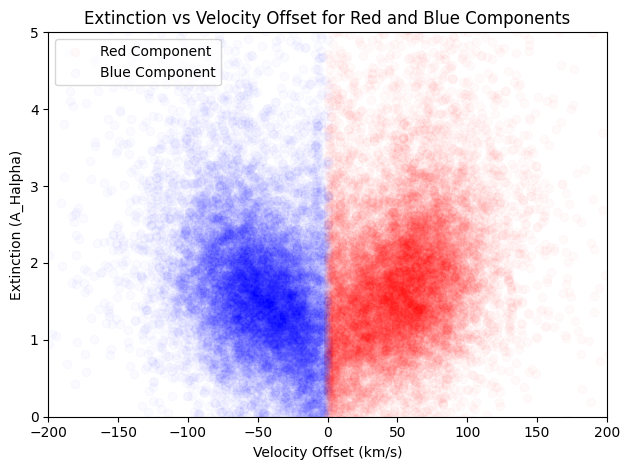

In [7]:
plt.scatter(dps_df['DV_R'], A_halpha_r, alpha=0.02, label='Red Component', color='r')
plt.scatter(dps_df['DV_L'], A_halpha_l, alpha=0.02, label='Blue Component', color='b')
plt.xlim(left=-200, right=200)
plt.ylim(bottom=0, top=5)
plt.xlabel('Velocity Offset (km/s)')
plt.ylabel('Extinction (A_Halpha)')
plt.legend()
plt.title('Extinction vs Velocity Offset for Red and Blue Components')
plt.tight_layout()
plt.savefig('./figures/Mar26/extinction.png')
plt.show()